# Customer Retention & Churn Analysis

### IMPORTING LIBRARIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['font.size'] = 12


# COLOUR PALETTE FOR CHURN AND RETAINED
CHURN_COLORS = ['#42A5F5', '#EF5350']  # Blue = Retained, Red = Churned


### LOADING THE DATASET

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns')
df.head()


Dataset loaded: 7,043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### UNDERSTANDING THE DATASET

In [5]:
print('========= COLOUMN INFO ============')
print(df.info())

print('\n========= MISSING VALUES ============')
print(df.isnull().sum())

print('\n========= BASIC STATISTICS ============')
df.describe()

========= COLOUMN INFO ============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### DATA CLEANING

In [6]:
# CONVERTING TOTALCHARGES TO NUMERIC
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# FILLING MISSING TOTALCHARGES WITH MISSING CHARGES ( NEW CUSTOMERS )
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# CONVERTING CHURN TO BINARY
df['ChurnBinary'] = (df['Churn'] == 'Yes').astype(int)

# CREATING TENURE GROUPS FOR COHORT ANALYSIS
df['TenureGroup'] = pd.cut(df['tenure'],
                            bins = [0,12,24,36,48,60,72],
                            labels = ['0-12 months', '13-24 months', '25-36 months',
                                    '37-48 months', '49-60 months', '61-72 months'])


# 5. CREATING MONTHLY CHARGE GROUPS
df['ChargeGroup'] = pd.cut(df['MonthlyCharges'],
                            bins=[0, 30, 60, 90, 120],
                            labels=['Low ($0-30)', 'Medium ($30-60)',
                                    'High ($60-90)', 'Very High ($90+)'])

### KPI ( KEY PERFORMANCE INDICATOR ) SUMMARY

In [11]:
total_customers = len(df)
churned = df['ChurnBinary'].sum()
retained = total_customers - churned
churn_rate = churned/total_customers * 100
retention_rate = retained/total_customers * 100
avg_tenure = df['tenure'].mean()
avg_monthly = df['MonthlyCharges'].mean()
avg_tenure_churned = df[df['Churn']=='Yes']['tenure'].mean()
revenue_lost = df[df['Churn']=='Yes']['MonthlyCharges'].sum()




print('=' * 50)
print('   KEY CHURN & RETENTION METRICS')
print('=' * 50)
print(f'  Total Customers       : {total_customers:,}')
print(f'  Retained Customers    : {retained:,}')
print(f'  Churned Customers     : {churned:,}')
print(f'  Churn Rate            : {churn_rate:.1f}%')
print(f'  Retention Rate        : {retention_rate:.1f}%')
print(f'  Avg Customer Tenure   : {avg_tenure:.1f} months')
print(f'  Avg Tenure (Churned)  : {avg_tenure_churned:.1f} months')
print(f'  Avg Monthly Charge    : ${avg_monthly:.2f}')
print(f'  Monthly Revenue at Risk: ${revenue_lost:,.2f}')
print('=' * 50)


   KEY CHURN & RETENTION METRICS
  Total Customers       : 7,043
  Retained Customers    : 5,174
  Churned Customers     : 1,869
  Churn Rate            : 26.5%
  Retention Rate        : 73.5%
  Avg Customer Tenure   : 32.4 months
  Avg Tenure (Churned)  : 18.0 months
  Avg Monthly Charge    : $64.76
  Monthly Revenue at Risk: $139,130.85


### OVERALL CHURN VS RETENTION

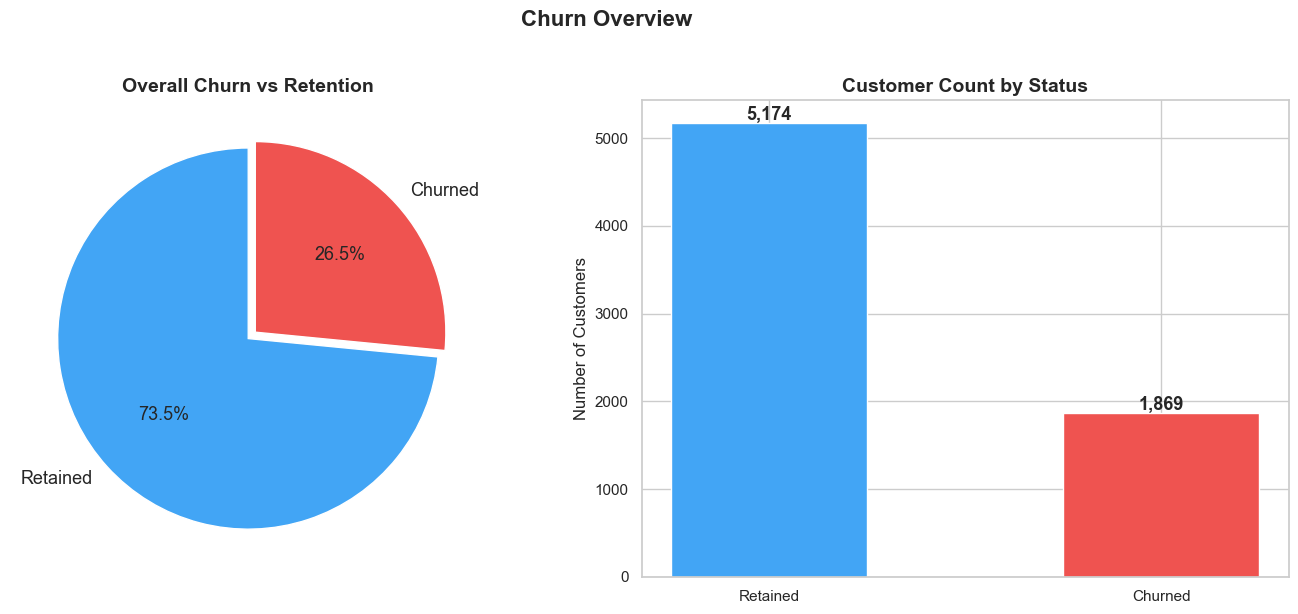

In [16]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))


# PIE CHART
churn_counts = df['Churn'].value_counts()
ax1.pie(churn_counts, labels = ['Retained', 'Churned'],
        autopct='%1.1f%%', colors=CHURN_COLORS,
        startangle=90, explode=(0,0.05),
        textprops={'fontsize':13})
ax1.set_title('Overall Churn vs Retention', fontweight='bold', fontsize=14)



# BAR CHART
bars = ax2.bar(['Retained', 'Churned'], churn_counts.values, color=CHURN_COLORS, width=0.5)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 30,
            f'{height:,}', ha='center', fontsize=13, fontweight='bold')
ax2.set_title('Customer Count by Status', fontweight='bold', fontsize=14)
ax2.set_ylabel('Number of Customers')
plt.suptitle('Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY TENURE GROUP ( COHORT ANALYSIS )

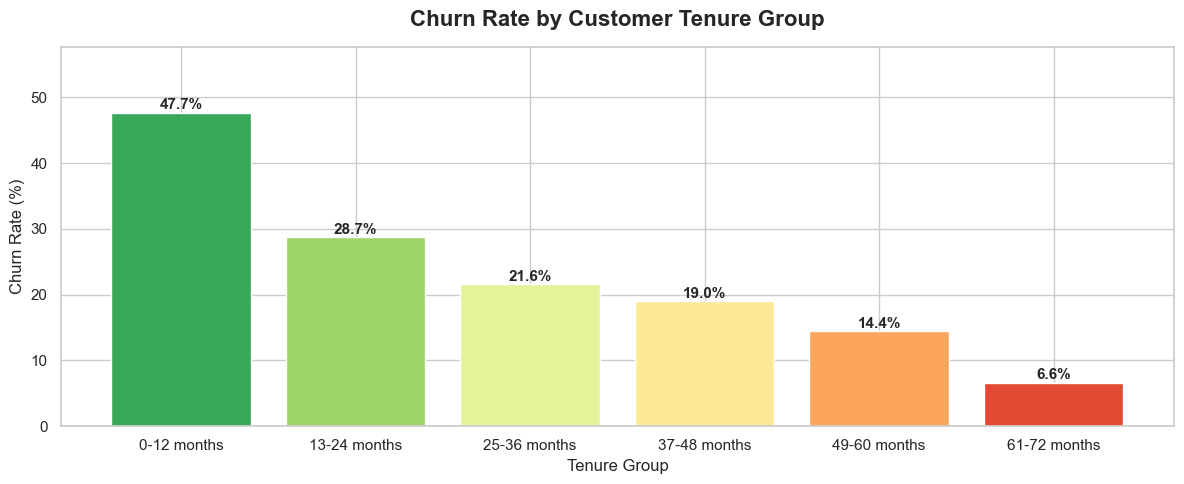

In [17]:
tenure_churn = df.groupby('TenureGroup')['ChurnBinary'].agg(['mean', 'count']).reset_index()
tenure_churn['ChurnRate'] = tenure_churn['mean']*100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(tenure_churn['TenureGroup'].astype(str),
                tenure_churn['ChurnRate'],
                color=sns.color_palette('RdYlGn_r', len(tenure_churn)))


for bar, rate in zip(bars, tenure_churn['ChurnRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
    f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')


ax.set_title('Churn Rate by Customer Tenure Group', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tenure Group', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, max(tenure_churn['ChurnRate']) + 10)
plt.tight_layout()
plt.savefig('chart_02_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY CONTRACT TYPE

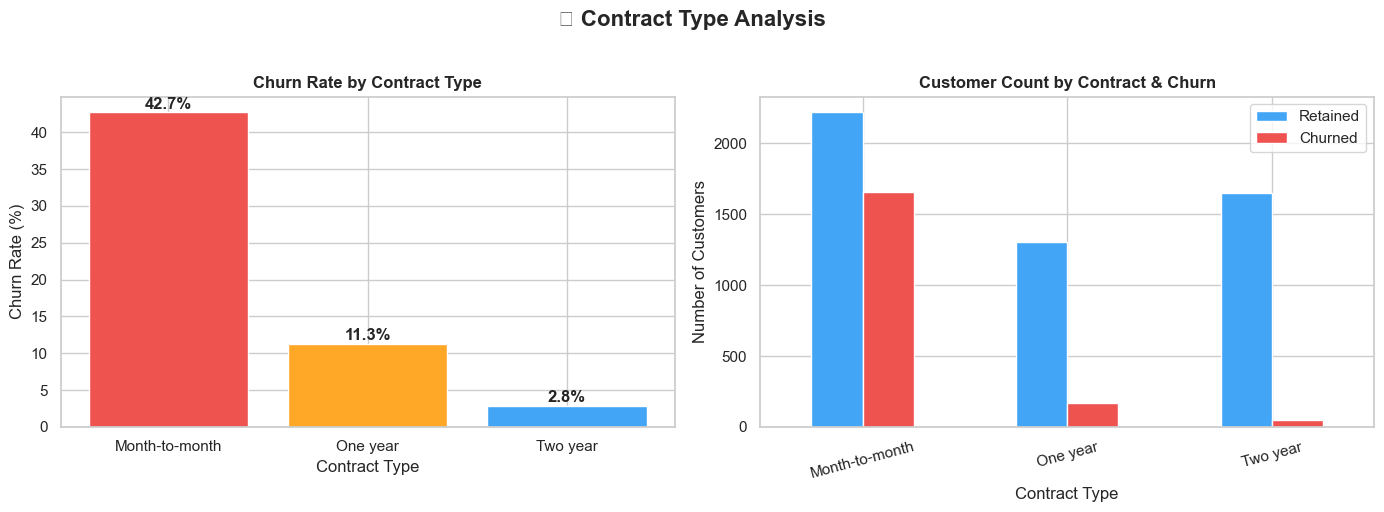

In [ ]:
contract_churn = df.groupby('Contract')['ChurnBinary'].mean().reset_index()
contract_churn['ChurnRate'] = contract_churn['ChurnBinary'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by contract
colors = ['#EF5350', '#FFA726', '#42A5F5']
bars = ax1.bar(contract_churn['Contract'], contract_churn['ChurnRate'], color=colors)
for bar, rate in zip(bars, contract_churn['ChurnRate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontweight='bold')
ax1.set_title('Churn Rate by Contract Type', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xlabel('Contract Type')

# Customer distribution by contract
contract_dist = df.groupby(['Contract', 'Churn']).size().unstack()
contract_dist.plot(kind='bar', ax=ax2, color=CHURN_COLORS, rot=15)
ax2.set_title('Customer Count by Contract & Churn', fontweight='bold')
ax2.set_ylabel('Number of Customers')
ax2.set_xlabel('Contract Type')
ax2.legend(['Retained', 'Churned'])

plt.suptitle('📋 Contract Type Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_03_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY MONTHLY CHARGES

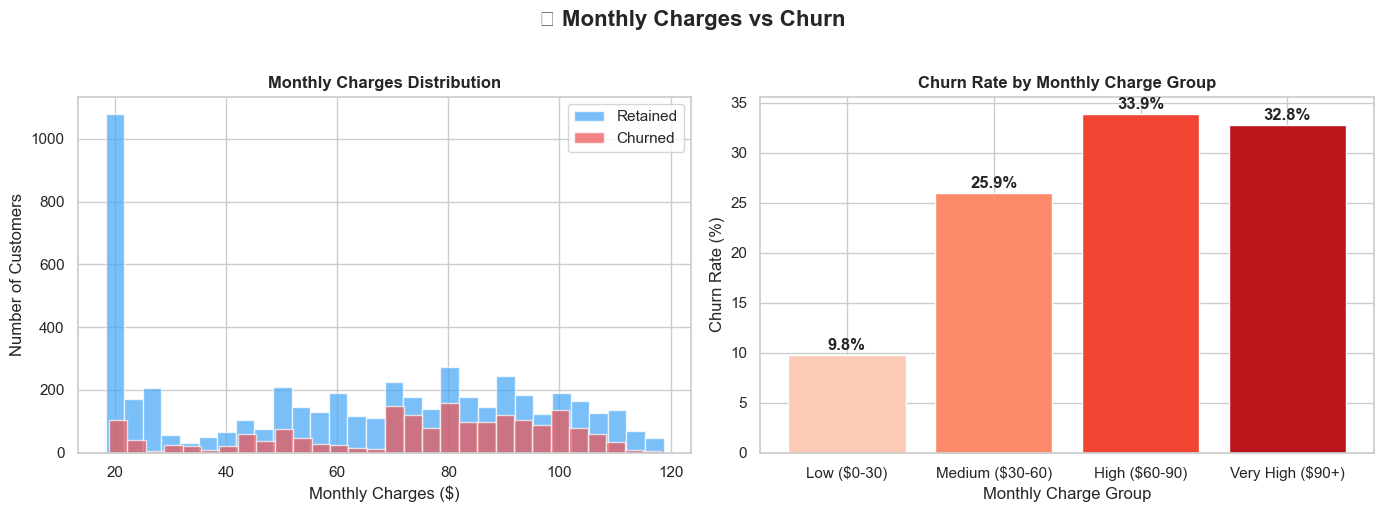

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))



# DISTRIBUTION OF MONTHLY CHARGES BY CHURN STATUS
df[df['Churn']=='No']['MonthlyCharges'].hist(ax=ax1, bins=30, alpha=0.7,
                            color='#42A5F5', label='Retained')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=ax1, bins = 30, alpha=0.7,
                    color='#EF5350', label='Churned')
ax1.set_title('Monthly Charges Distribution', fontweight='bold')
ax1.set_xlabel('Monthly Charges ($)')
ax1.set_ylabel('Number of Customers')
ax1.legend()



# CHURN RATE BY CHARGE GROUP
charge_churn = df.groupby('ChargeGroup')['ChurnBinary'].mean().reset_index()
charge_churn['ChurnRate'] = charge_churn['ChurnBinary']*100
bars = ax2.bar(charge_churn['ChargeGroup'].astype(str),
               charge_churn['ChurnRate'],
               color=sns.color_palette('Reds', len(charge_churn)))
for bar, rate in zip(bars, charge_churn['ChurnRate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontweight='bold')
ax2.set_title('Churn Rate by Monthly Charge Group', fontweight='bold')
ax2.set_xlabel('Monthly Charge Group')
ax2.set_ylabel('Churn Rate (%)')

plt.suptitle('💰 Monthly Charges vs Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_04_churn_by_charges.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY INTERNET SERVICE AND KEY SERVICES

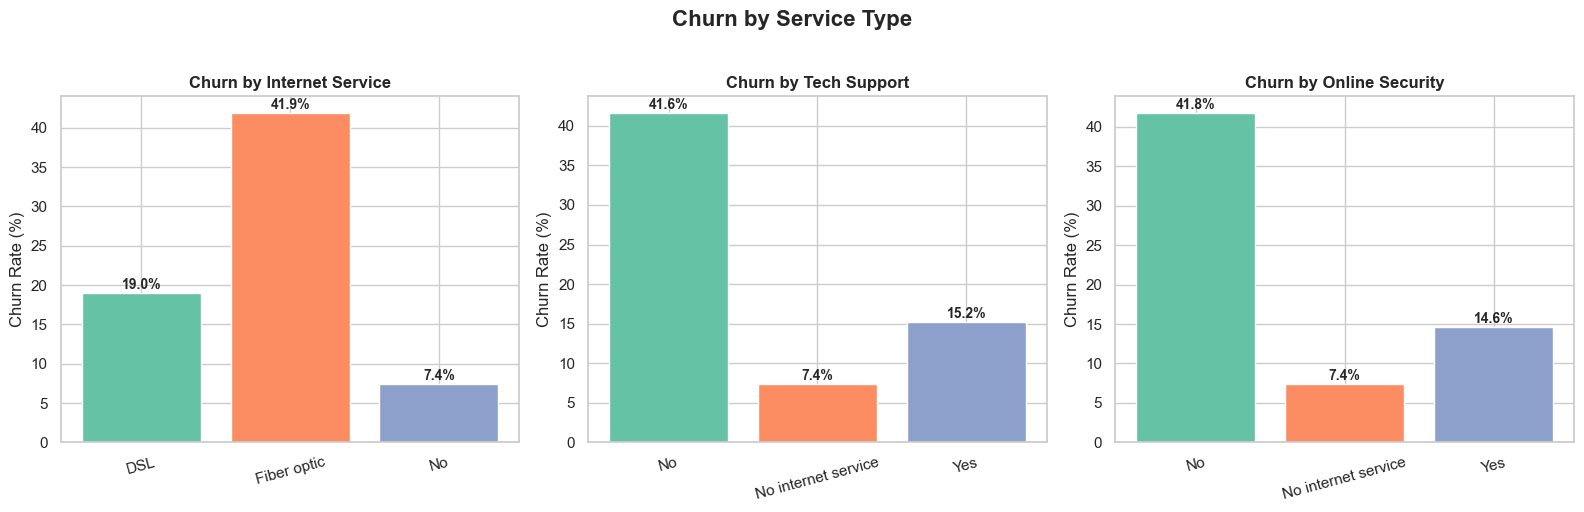

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

service_cols = ['InternetService', 'TechSupport', 'OnlineSecurity']
titles = ['Internet Service', 'Tech Support', 'Online Security']

for ax, col, title in zip(axes, service_cols, titles):
    churn_rate = df.groupby(col)['ChurnBinary'].mean()*100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                color=sns.color_palette('Set2', len(churn_rate)))

    for bar, rate in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'Churn by {title}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Churn by Service Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_05_churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY DEMOGRAPHICS

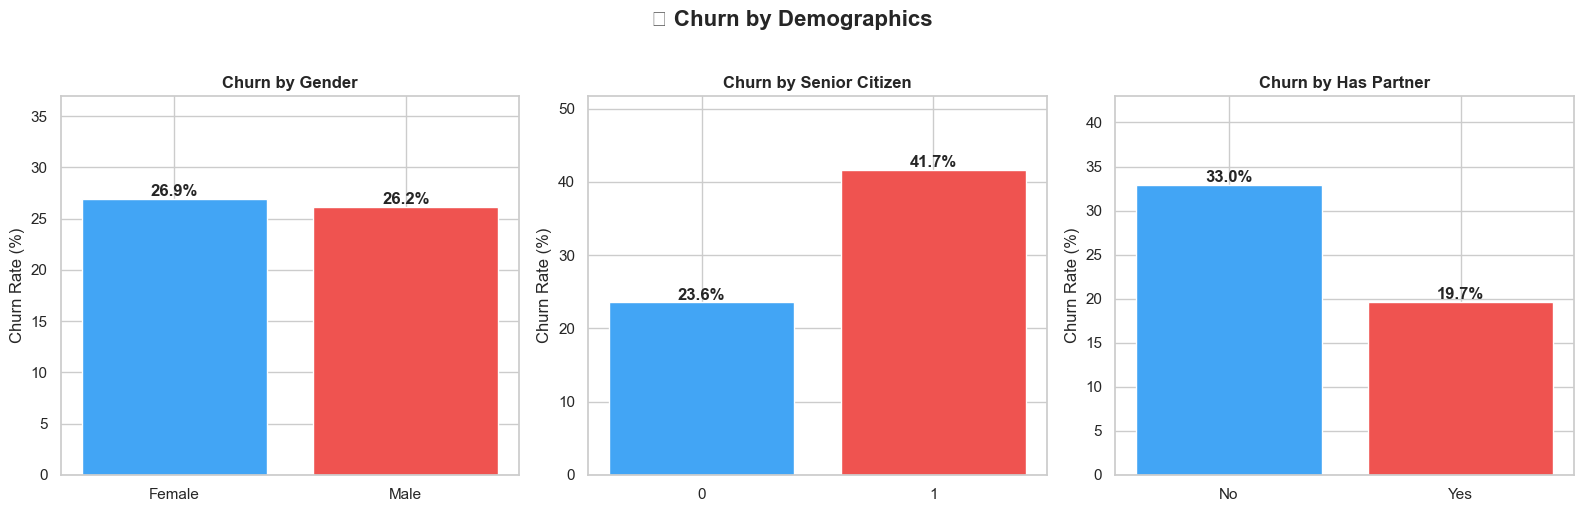

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

demo_cols = ['gender', 'SeniorCitizen', 'Partner']
titles = ['Gender', 'Senior Citizen', 'Has Partner']

for ax, col, title in zip(axes, demo_cols, titles):
    churn_rate = df.groupby(col)['ChurnBinary'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color=['#42A5F5', '#EF5350'])
    for bar, rate in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', fontweight='bold')
    ax.set_title(f'Churn by {title}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, max(churn_rate.values) + 10)

plt.suptitle('👤 Churn by Demographics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_06_churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

### CHURN BY PAYMENT METHODS

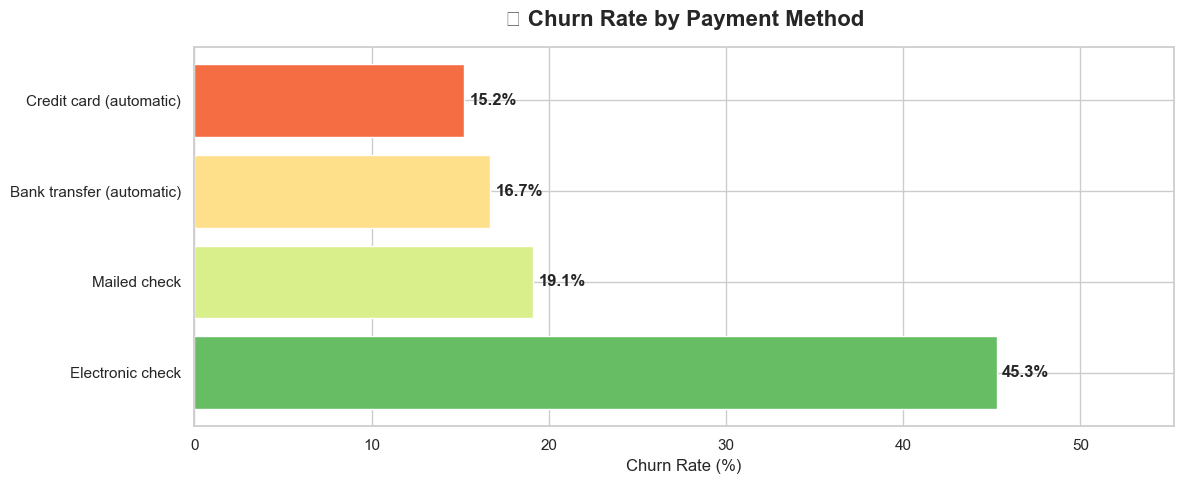

In [31]:
payment_churn = df.groupby('PaymentMethod')['ChurnBinary'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(payment_churn.index, payment_churn.values,
               color=sns.color_palette('RdYlGn_r', len(payment_churn)))
for bar, rate in zip(bars, payment_churn.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontweight='bold')
ax.set_title('💳 Churn Rate by Payment Method', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, max(payment_churn.values) + 10)
plt.tight_layout()
plt.savefig('chart_07_churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

# HEATMAP

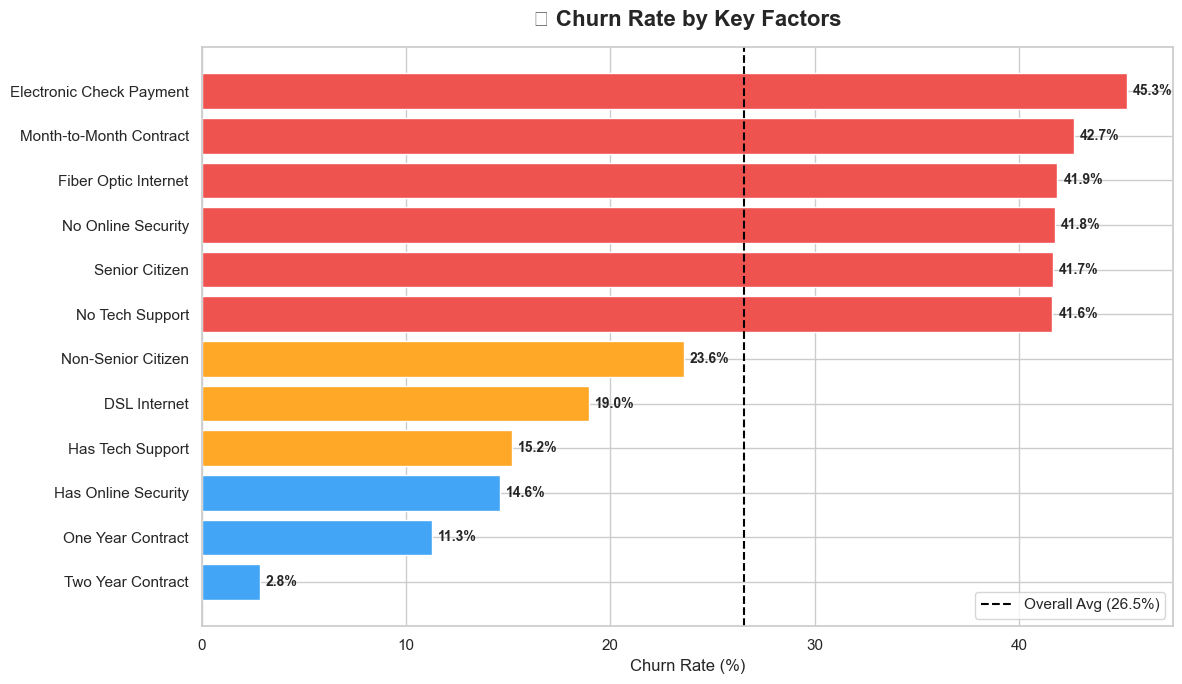

In [32]:
# BUILDING A SUMMARY OF CHURN RATES ACROSS ALL KEY FACTORS
factors = {
    'Month-to-Month Contract': df[df['Contract']=='Month-to-month']['ChurnBinary'].mean() * 100,
    'One Year Contract':        df[df['Contract']=='One year']['ChurnBinary'].mean() * 100,
    'Two Year Contract':        df[df['Contract']=='Two year']['ChurnBinary'].mean() * 100,
    'No Online Security':       df[df['OnlineSecurity']=='No']['ChurnBinary'].mean() * 100,
    'Has Online Security':      df[df['OnlineSecurity']=='Yes']['ChurnBinary'].mean() * 100,
    'No Tech Support':          df[df['TechSupport']=='No']['ChurnBinary'].mean() * 100,
    'Has Tech Support':         df[df['TechSupport']=='Yes']['ChurnBinary'].mean() * 100,
    'Fiber Optic Internet':     df[df['InternetService']=='Fiber optic']['ChurnBinary'].mean() * 100,
    'DSL Internet':             df[df['InternetService']=='DSL']['ChurnBinary'].mean() * 100,
    'Senior Citizen':           df[df['SeniorCitizen']==1]['ChurnBinary'].mean() * 100,
    'Non-Senior Citizen':       df[df['SeniorCitizen']==0]['ChurnBinary'].mean() * 100,
    'Electronic Check Payment': df[df['PaymentMethod']=='Electronic check']['ChurnBinary'].mean() * 100,
}

factors_df = pd.DataFrame(list(factors.items()), columns=['Factor', 'ChurnRate'])
factors_df = factors_df.sort_values('ChurnRate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#EF5350' if r > 30 else '#FFA726' if r > 15 else '#42A5F5'
          for r in factors_df['ChurnRate']]
bars = ax.barh(factors_df['Factor'], factors_df['ChurnRate'], color=colors)
for bar, rate in zip(bars, factors_df['ChurnRate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=df['ChurnBinary'].mean()*100, color='black',
           linestyle='--', linewidth=1.5, label=f'Overall Avg ({df["ChurnBinary"].mean()*100:.1f}%)')
ax.set_title('🔥 Churn Rate by Key Factors', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('chart_08_churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

### KEY INSIGHTS AND RECOMMENDATIONS

In [33]:
churn_rate        = df['ChurnBinary'].mean() * 100
mtm_churn         = df[df['Contract']=='Month-to-month']['ChurnBinary'].mean() * 100
twoyear_churn     = df[df['Contract']=='Two year']['ChurnBinary'].mean() * 100
new_churn         = df[df['TenureGroup']=='0-12 months']['ChurnBinary'].mean() * 100
senior_churn      = df[df['SeniorCitizen']==1]['ChurnBinary'].mean() * 100
fiber_churn       = df[df['InternetService']=='Fiber optic']['ChurnBinary'].mean() * 100
echeck_churn      = df[df['PaymentMethod']=='Electronic check']['ChurnBinary'].mean() * 100
revenue_at_risk   = df[df['Churn']=='Yes']['MonthlyCharges'].sum()

print('=' * 58)
print('      💡 KEY INSIGHTS & RECOMMENDATIONS')
print('=' * 58)
print(f"""
--> INSIGHT 1 — Overall Churn Rate: {churn_rate:.1f}%
   Industry benchmark is ~5-7%. At {churn_rate:.1f}%, this business
   needs urgent retention intervention.
   → Set a target to reduce churn to below 15% in 6 months.

--> INSIGHT 2 — Contract Type is the #1 Churn Driver:
   Month-to-month churn: {mtm_churn:.1f}% vs Two-year: {twoyear_churn:.1f}%
   → Offer discounts/incentives to move customers
     from monthly to annual contracts.

--> INSIGHT 3 — New Customers Churn the Most:
   0-12 month customers churn at {new_churn:.1f}%
   → Invest in onboarding experience and early
     engagement programs for new customers.

--> INSIGHT 4 — Senior Citizens Are High Risk:
   Senior citizen churn rate: {senior_churn:.1f}%
   → Create senior-specific support programs
     and simplified pricing plans.

--> INSIGHT 5 — Fiber Optic Customers Churn More:
   Fiber optic churn: {fiber_churn:.1f}%
   → Investigate service quality issues.
   → Offer loyalty rewards for fiber customers.

--> INSIGHT 6 — Electronic Check = High Churn:
   Electronic check churn: {echeck_churn:.1f}%
   → Incentivize customers to switch to
     auto-pay (bank transfer/credit card).

--> INSIGHT 7 — Monthly Revenue at Risk:
   ${revenue_at_risk:,.2f}/month from churned customers
   → Even retaining 20% of churned customers
     saves ${revenue_at_risk*0.2:,.2f}/month.
""")
print('=' * 58)

      💡 KEY INSIGHTS & RECOMMENDATIONS

--> INSIGHT 1 — Overall Churn Rate: 26.5%
   Industry benchmark is ~5-7%. At 26.5%, this business
   needs urgent retention intervention.
   → Set a target to reduce churn to below 15% in 6 months.

--> INSIGHT 2 — Contract Type is the #1 Churn Driver:
   Month-to-month churn: 42.7% vs Two-year: 2.8%
   → Offer discounts/incentives to move customers
     from monthly to annual contracts.

--> INSIGHT 3 — New Customers Churn the Most:
   0-12 month customers churn at 47.7%
   → Invest in onboarding experience and early
     engagement programs for new customers.

--> INSIGHT 4 — Senior Citizens Are High Risk:
   Senior citizen churn rate: 41.7%
   → Create senior-specific support programs
     and simplified pricing plans.

--> INSIGHT 5 — Fiber Optic Customers Churn More:
   Fiber optic churn: 41.9%
   → Investigate service quality issues.
   → Offer loyalty rewards for fiber customers.

--> INSIGHT 6 — Electronic Check = High Churn:
   Electroni

### EXPORT SUMMARY CSVs for Visualisation

In [34]:
# SAVING CLEAN DATASET
df.to_csv('telco_churn_cleaned.csv', index=False)

# SAVING CHURN BY TENURE
tenure_churn.to_csv('summary_churn_by_tenure.csv', index=False)

# SAVING CHURN FACTORY SUMMARY
factors_df.to_csv('summary_churn_drivers.csv', index=False)